In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### 1) load the given dataset 

In [3]:
df=pd.read_excel(r"C:\Users\DELL\Documents\Fingertips\try data\project all\ML Project KNN Loan Applicant Credit Risk Analysis Credit Risk Analysis is K-Nearest Neighbours\ML Project - KNN Loan Applicant Credit Risk Analysis U 16955473070.xlsx")

In [4]:
df.head()

,Age,Total Work Experience,Number of years in city,Cost to Request Ratio,Cibil score,Overdrafts past12months,Total bounces past12months
0,40.50,2,6,0.842666,594,0,0
1,41.25,5,2,0.791667,754,0,0
2,39.50,5,2,0.727273,779,0,0
3,35.00,1,4,0.820232,818,0,0
4,34.00,3,3,0.455581,853,0,1


### 2) Check for the null values 

In [10]:
df.isnull().sum()

Age                           0
Total Work Experience         0
Number of years in city       0
Cost to Request Ratio         0
Cibil score                   0
Overdrafts past12months       0
Total bounces past12months    0
dtype: int64

### 3) Get basic information from data 

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8995 entries, 0 to 8994
Data columns (total 7 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         8995 non-null   float64
 1   Total Work Experience       8995 non-null   int64  
 2   Number of years in city     8995 non-null   int64  
 3   Cost to Request Ratio       8995 non-null   float64
 4   Cibil score                 8995 non-null   int64  
 5   Overdrafts past12months     8995 non-null   int64  
 6   Total bounces past12months  8995 non-null   int64  
dtypes: float64(2), int64(5)
memory usage: 492.0 KB


### 4) Describe the dataset 

In [12]:
df.describe()

,Age,Total Work Experience,Number of years in city,Cost to Request Ratio,Cibil score,Overdrafts past12months,Total bounces past12months
count,8995.000000,8995.000000,8995.000000,8995.000000,8995.000000,8995.000000,8995.000000
mean,38.808202,2.131073,4.288160,0.831183,752.626570,0.322068,1.162757
std,10.203371,0.892141,1.269416,0.490216,67.645792,0.914998,2.352798
min,18.100000,1.000000,1.000000,0.008466,351.000000,0.000000,0.000000
25%,30.830000,1.000000,3.000000,0.662147,730.000000,0.000000,0.000000
50%,37.200000,2.000000,4.000000,0.800000,768.000000,0.000000,0.000000
75%,45.400000,3.000000,5.000000,0.930908,797.000000,0.000000,1.000000
max,83.800000,5.000000,6.000000,12.006623,882.000000,12.000000,12.000000


In [13]:
df.columns

Index(['Age', 'Total Work Experience', 'Number of years in city',
       'Cost to Request Ratio', 'Cibil score', 'Overdrafts past12months',
       'Total bounces past12months'],
      dtype='object')

### 5) Display scatterplot between age & Total work Experience 

In [14]:
df.columns=df.columns.str.replace(" ","_")

In [15]:
df.columns

Index(['Age', 'Total_Work_Experience', 'Number_of_years_in_city',
       'Cost_to_Request_Ratio', 'Cibil_score', 'Overdrafts_past12months',
       'Total_bounces_past12months'],
      dtype='object')

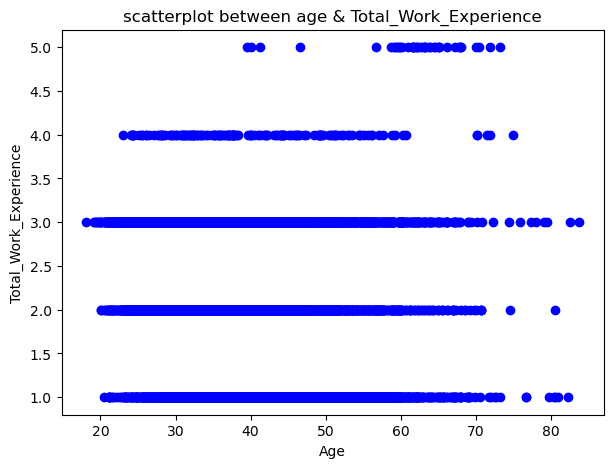

In [19]:
plt.figure(figsize=(7,5))
plt.scatter(df['Age'],df['Total_Work_Experience'],color='blue')
plt.title("scatterplot between age & Total_Work_Experience")
plt.xlabel('Age')
plt.ylabel('Total_Work_Experience')
plt.show()

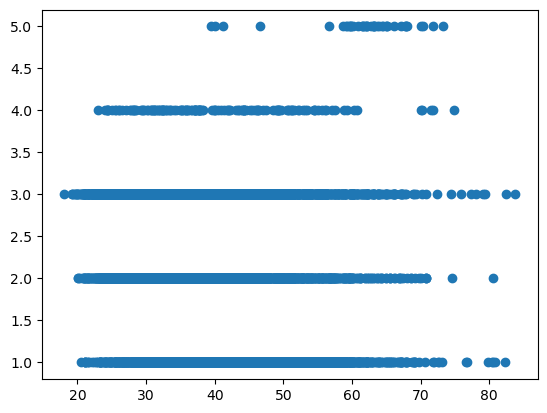

In [20]:
# both are same
plt.scatter(df['Age'],df['Total_Work_Experience'])

### 6) Display box plot for age 

<function matplotlib.pyplot.show(close=None, block=None)>

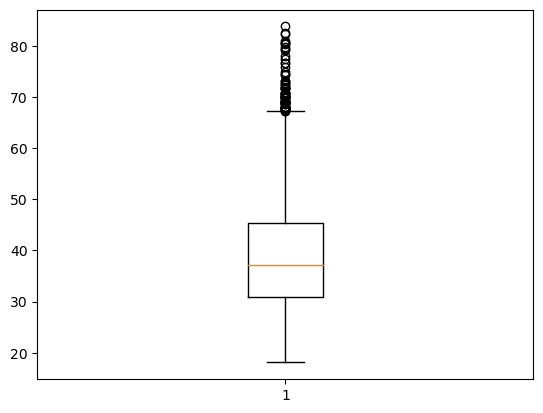

In [22]:
plt.boxplot(df['Age'])
plt.show

###  7) Display box plot for Cibil score 

<function matplotlib.pyplot.show(close=None, block=None)>

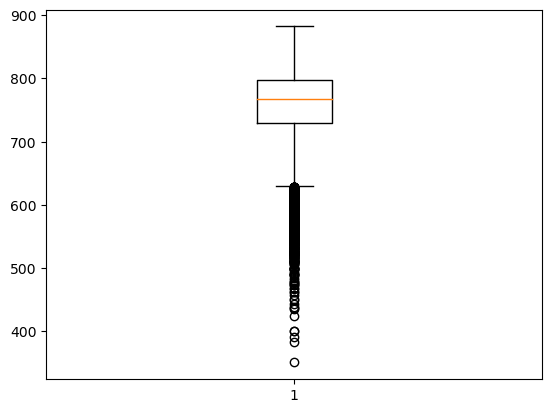

In [24]:
plt.boxplot(df['Cibil_score'])
plt.show

### 8) Create target and features data where target is Total bounces past 12 months

In [25]:
x=df.drop('Total_bounces_past12months',axis=1)

In [26]:
y=df['Total_bounces_past12months']

In [27]:
x

,Age,Total_Work_Experience,Number_of_years_in_city,Cost_to_Request_Ratio,Cibil_score,Overdrafts_past12months
0,40.50,2,6,0.842666,594,0
1,41.25,5,2,0.791667,754,0
2,39.50,5,2,0.727273,779,0
3,35.00,1,4,0.820232,818,0
4,34.00,3,3,0.455581,853,0
...,...,...,...,...,...,...
8990,30.80,3,3,0.596748,763,0
8991,31.83,3,6,0.986793,532,0
8992,32.67,2,5,0.628330,590,0
8993,37.00,3,3,0.797193,812,0


In [28]:
y

0       0
1       0
2       0
3       0
4       1
       ..
8990    0
8991    0
8992    0
8993    0
8994    0
Name: Total_bounces_past12months, Length: 8995, dtype: int64

## Part-2: Working with Model

### 1) Split data into training and testing sets 

In [29]:
from sklearn.model_selection import train_test_split

In [31]:
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.2)

### 2) Create a KNN classifier between Features and target data

In [32]:
from sklearn.neighbors import KNeighborsClassifier

In [33]:
knn=KNeighborsClassifier()

In [34]:
knn.fit(x_train,y_train)

KNeighborsClassifier()

### 3) Display the test score 

In [36]:
knn.score(x_test,y_test)

C:\Users\DELL\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)


0.6309060589216231

### 4) Display the training score

In [37]:
knn.score(x_train,y_train)

C:\Users\DELL\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)


0.6637020566981656

In [39]:
y_pred=knn.predict(x_test)

C:\Users\DELL\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)


### 5) Print the accuracy score 

In [41]:
from sklearn.metrics import accuracy_score

In [44]:
accuracy_score(y_test,y_pred)

0.6309060589216231

### 6) Try 1 to 14 k values for classifier 

In [46]:
from sklearn.neighbors import KNeighborsClassifier

test_scores=[]
train_scores=[]
for i in range(1,15):
    model=KNeighborsClassifier(i)
    model.fit(x_train,y_train)

    train_scores.append(model.score(x_train,y_train))
    test_scores.append(model.score(x_test,y_test))

C:\Users\DELL\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)
C:\Users\DELL\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims`

C:\Users\DELL\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)
C:\Users\DELL\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims`

In [47]:
test_scores

[0.5051417454141189,
 0.6085325180655919,
 0.6127015008337966,
 0.6239577543079489,
 0.6309060589216231,
 0.6381322957198443,
 0.6386881600889383,
 0.6429961089494164,
 0.6445247359644247,
 0.6481378543635353,
 0.6485547526403558,
 0.6493885491939967,
 0.6500833796553641,
 0.650639244024458]

In [50]:
train_scores

[1.0,
 0.7292940522512507,
 0.6964980544747081,
 0.6809338521400778,
 0.6637020566981656,
 0.6625903279599777,
 0.659811006114508,
 0.6570316842690384,
 0.6548082267926626,
 0.6503613118399111,
 0.6481378543635353,
 0.6492495831017232,
 0.6492495831017232,
 0.6498054474708171]

### 7) Display training and testing score for all the 1 to 14 k values

<function matplotlib.pyplot.show(close=None, block=None)>

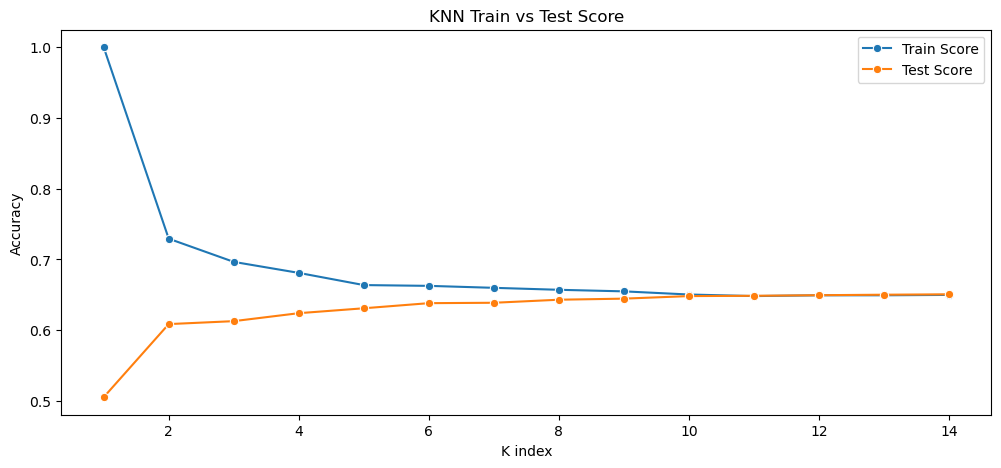

In [60]:
plt.figure(figsize=(12,5))
sns.lineplot(x=list(range(1,len(train_scores)+1)),y=train_scores,marker='o',label='Train Score')
sns.lineplot(x=list(range(1,len(test_scores)+1)),y=test_scores,marker='o',label='Test Score')
plt.title("KNN Train vs Test Score")
plt.xlabel("K index")
plt.ylabel("Accuracy")
plt.legend()
plt.show